In [9]:
!pip install xgboost lightgbm

In [37]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

df = pd.read_csv('bike_train.csv')
df.head(30)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [13]:
df['datetime'] = pd.to_datetime(df['datetime'])

#datetime파생변수
df['year'] = df.datetime.dt.year
df['month'] = df.datetime.dt.month
df['day'] = df.datetime.dt.day
df['hour'] = df.datetime.dt.hour
df['weekday'] = df.datetime.dt.weekday

#주말 그룹
df['weekend'] = (df.weekday >= 5).astype(int)

#시간 그룹
def time_label(hour):
    if 7 <= hour <= 9 :
        return 0
    elif 17 <= hour <= 19 :
        return 1
    else :
        return 2 
df['time_group'] = df.hour.apply(time_label)

# 계절, 날씨 원핫인코딩
df['bad_weather'] = (df['weather'] >= 3).astype(int)

df = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True)

# 온도
def temp_label(temp):
    if temp < 10 :
        return 0
    elif temp < 20 :
        return 1
    else : 
        return 2
df['temp_group'] = df.temp.apply(temp_label)

# 체감온도 + 습도
def comfort_label(row):
    atemp = row['atemp']
    humidity = row['humidity']
    
    if atemp >= 25 and humidity >= 70 :
        return 0   # 고온다습
    elif atemp >= 25 and humidity < 70 :
        return 1   # 고온건조
    elif 15 <= atemp < 25 and humidity >= 70 :
        return 2   # 온난습윤
    elif 15 <= atemp < 25 and humidity < 70 :
        return 3   # 온난건조
    else:
        return 4   # 저온건조
df['comfort_group'] = df.apply(comfort_label, axis=1)

# 불쾌지수
df['discomfort_index'] = (
    0.81 * df['atemp'] +
    0.01 * df['humidity'] * (0.99 * df['atemp'] - 14.3) +
    46.3
)
def di_label(x):
    if x < 68 :
        return 0   # 쾌적
    elif x < 75 :
        return 1   # 보통
    elif x < 80 :
        return 2   # 불쾌
    else:
        return 3   # 매우 불쾌

df['di_group'] = df['discomfort_index'].apply(di_label)

# 풍속
def wind_label(w):
    if w >= 15 :
        return 0   # 강함
    elif w > 5 :
        return 1   # 적당함
    else :
        return 2   # 약하거나 안붐

df['wind_group'] = df['windspeed'].apply(wind_label)

# 사람이 느끼는 온도 차이 
df['temp_diff'] = df['atemp'] - df['temp']

# 습도 + 풍속
df['humidity_wind'] = df['humidity'] * df['windspeed']

# 스케일링
df['count_log'] = np.log1p(df['count'])

for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

# 컬럼삭제
df = df.drop(['datetime','casual','registered'], axis=1)

df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   holiday           10886 non-null  int64  
 1   workingday        10886 non-null  int64  
 2   temp              10886 non-null  float64
 3   atemp             10886 non-null  float64
 4   humidity          10886 non-null  int64  
 5   windspeed         10886 non-null  float64
 6   count             10886 non-null  int64  
 7   year              10886 non-null  int32  
 8   month             10886 non-null  int32  
 9   day               10886 non-null  int32  
 10  hour              10886 non-null  int32  
 11  weekday           10886 non-null  int32  
 12  weekend           10886 non-null  int64  
 13  time_group        10886 non-null  int64  
 14  bad_weather       10886 non-null  int64  
 15  season_2          10886 non-null  int64  
 16  season_3          10886 non-null  int64 

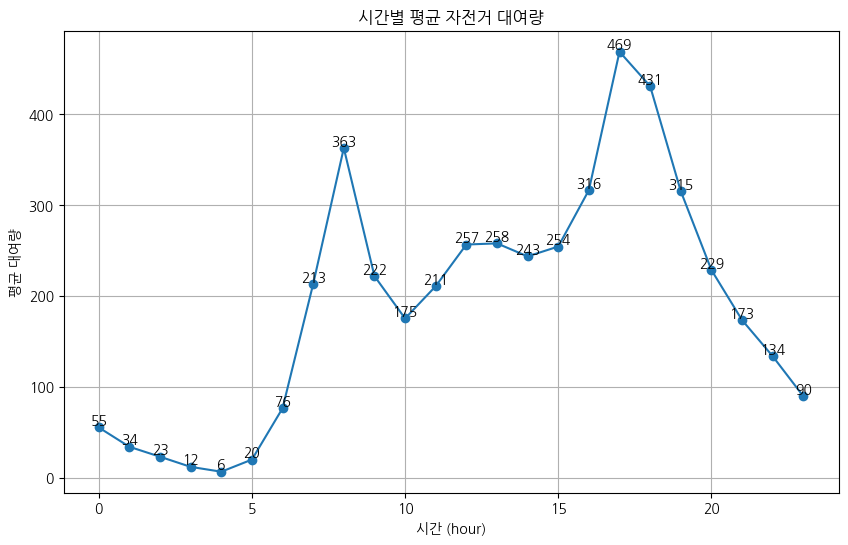

In [16]:
#시각화 
#시간별 평균 대여량
hour_mean = df.groupby('hour')['count'].mean()

plt.figure(figsize=(10,6))
plt.plot(hour_mean.index, hour_mean.values, marker='o')

plt.title('시간별 평균 자전거 대여량')
plt.xlabel('시간 (hour)')
plt.ylabel('평균 대여량')

for x, y in zip(hour_mean.index, hour_mean.values):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom')

plt.grid()
plt.show()

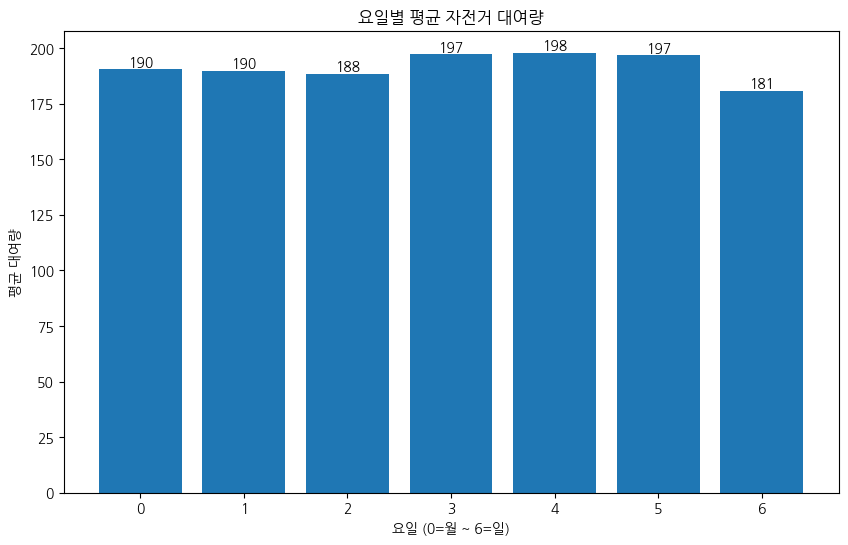

In [17]:
# 요일별 평균 자전거 대여량
weekday_mean = df.groupby('weekday')['count'].mean()

plt.figure(figsize=(10,6))
bars = plt.bar(weekday_mean.index, weekday_mean.values)

plt.title('요일별 평균 자전거 대여량')
plt.xlabel('요일 (0=월 ~ 6=일)')
plt.ylabel('평균 대여량')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.0f}', ha='center', va='bottom')

plt.show()

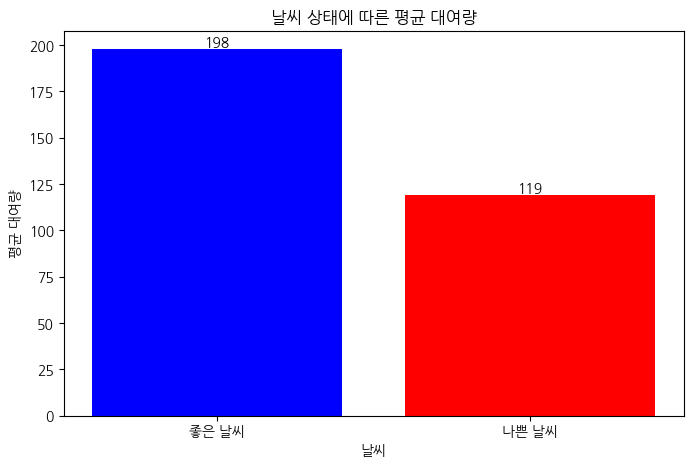

In [23]:
#날씨별 대여량 
weather_mean = df.groupby('bad_weather')['count'].mean()

plt.figure(figsize=(8,5))
bars = plt.bar(['좋은 날씨', '나쁜 날씨'], weather_mean.values, color = ['blue','red'])

plt.title('날씨 상태에 따른 평균 대여량')
plt.xlabel('날씨')
plt.ylabel('평균 대여량')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.0f}', ha='center', va='bottom')

plt.show()

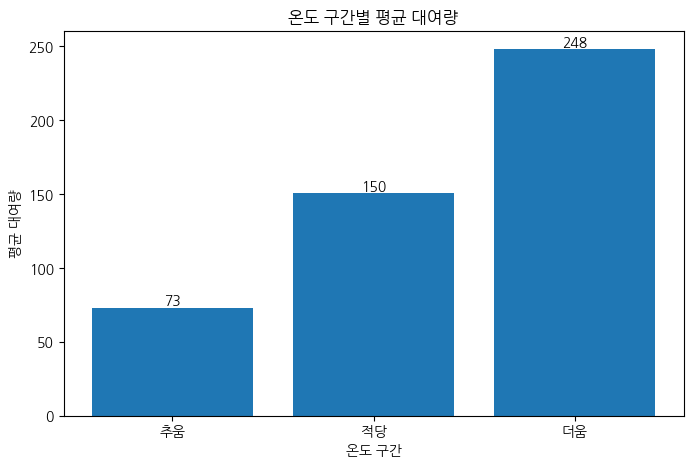

In [24]:
#온도별 대여량
temp_mean = df.groupby('temp_group')['count'].mean()

labels = ['추움', '적당', '더움']

plt.figure(figsize=(8,5))
bars = plt.bar(labels, temp_mean.values)

plt.title('온도 구간별 평균 대여량')
plt.xlabel('온도 구간')
plt.ylabel('평균 대여량')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.0f}', ha='center', va='bottom')

plt.show()

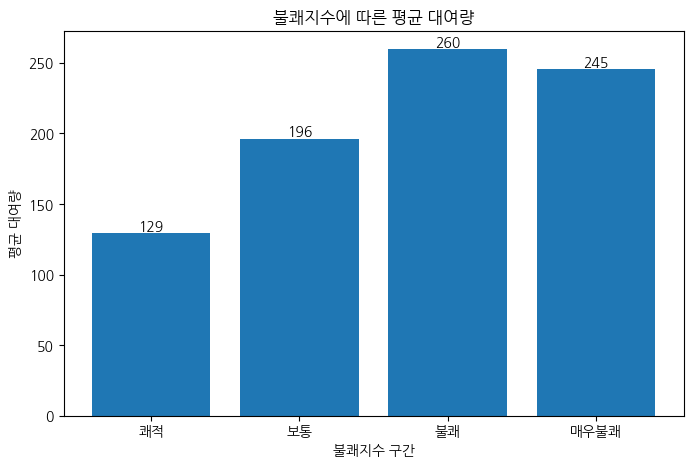

In [25]:
#불쾌지수별 대여량
di_mean = df.groupby('di_group')['count'].mean()

labels = ['쾌적', '보통', '불쾌', '매우불쾌']

plt.figure(figsize=(8,5))
bars = plt.bar(labels, di_mean.values)

plt.title('불쾌지수에 따른 평균 대여량')
plt.xlabel('불쾌지수 구간')
plt.ylabel('평균 대여량')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.0f}', ha='center', va='bottom')

plt.show()

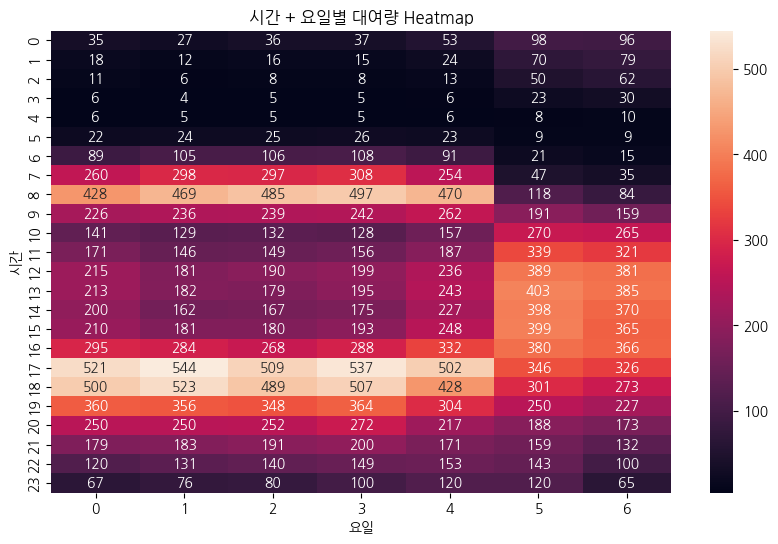

In [26]:
import seaborn as sns

pivot = df.pivot_table(values='count', index='hour', columns='weekday', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f')

plt.title('시간 + 요일별 대여량 Heatmap')
plt.xlabel('요일')
plt.ylabel('시간')

plt.show()

In [27]:
#데이터셋 분리 및 학습
X = df.drop(['count','count_log'], axis=1)
y = df['count_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [39]:
#평가함수 

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    # 1. 학습
    model.fit(X_train, y_train)
    
    # 2. 예측 (log 상태)
    pred = model.predict(X_test)
    
    # 3. 원래 스케일로 복원
    y_test_exp = np.expm1(y_test)
    pred_exp = np.expm1(pred)
    
    # 4. 평가 지표 계산
    mse = mean_squared_error(y_test_exp, pred_exp)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_exp, pred_exp)
    r2 = r2_score(y_test_exp, pred_exp)
    
    # 평균 대비 퍼센트 오차
    y_mean = y_test_exp.mean()
    nrmse = (rmse / y_mean) * 100
    nmae = (mae / y_mean) * 100
    r2_pct = r2 * 100
    
    # 5. 출력
    print('=' * 55)
    print(f'모델명 : {name}')
    print('=' * 55)
    print(f'MSE         : {mse:,.2f}')
    print(f'RMSE        : {rmse:,.2f}')
    print(f'MAE         : {mae:,.2f}')
    print(f'R²          : {r2:.4f}  ({r2_pct:.2f}%)')
    print(f'NRMSE(%)    : {nrmse:.2f}%')
    print(f'NMAE(%)     : {nmae:.2f}%')
    print()
    
    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'R2(%)': r2_pct,
        'NRMSE(%)': nrmse,
        'NMAE(%)': nmae
    }

In [40]:
lr = LinearRegression()

ridge = Ridge(alpha=1.0, random_state=42)

lasso = Lasso(alpha=0.001, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

gbm = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [41]:
results = []

results.append(evaluate_model('Linear Regression', lr, X_train, X_test, y_train, y_test))
results.append(evaluate_model('Ridge', ridge, X_train, X_test, y_train, y_test))
results.append(evaluate_model('Lasso', lasso, X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test))
results.append(evaluate_model('GBM', gbm, X_train, X_test, y_train, y_test))
results.append(evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test))
results.append(evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test))

모델명 : Linear Regression
MSE         : 19,810.78
RMSE        : 140.75
MAE         : 92.35
R²          : 0.3743  (37.43%)
NRMSE(%)    : 75.14%
NMAE(%)     : 49.30%

모델명 : Ridge
MSE         : 19,810.40
RMSE        : 140.75
MAE         : 92.35
R²          : 0.3743  (37.43%)
NRMSE(%)    : 75.14%
NMAE(%)     : 49.30%

모델명 : Lasso
MSE         : 19,730.30
RMSE        : 140.46
MAE         : 92.22
R²          : 0.3768  (37.68%)
NRMSE(%)    : 74.99%
NMAE(%)     : 49.24%



C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.945e+01, tolerance: 1.733e+00
  model = cd_fast.enet_coordinate_descent(


모델명 : Random Forest
MSE         : 3,231.87
RMSE        : 56.85
MAE         : 33.99
R²          : 0.8979  (89.79%)
NRMSE(%)    : 30.35%
NMAE(%)     : 18.15%

모델명 : GBM
MSE         : 2,133.85
RMSE        : 46.19
MAE         : 27.53
R²          : 0.9326  (93.26%)
NRMSE(%)    : 24.66%
NMAE(%)     : 14.70%

모델명 : XGBoost
MSE         : 1,652.84
RMSE        : 40.66
MAE         : 23.69
R²          : 0.9478  (94.78%)
NRMSE(%)    : 21.71%
NMAE(%)     : 12.65%

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 26
[LightGBM] [Info] Start training from score 4.603713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [43]:
result_df = pd.DataFrame(results)

result_df = result_df[
    ['Model', 'MSE', 'RMSE', 'MAE', 'R2(%)', 'NRMSE(%)', 'NMAE(%)']
]

result_df.style.format({
    'MSE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'MAE': '{:,.2f}',
    'R2(%)': '{:.2f}%',
    'NRMSE(%)': '{:.2f}%',
    'NMAE(%)': '{:.2f}%'
})

,Model,MSE,RMSE,MAE,R2(%),NRMSE(%),NMAE(%)
0,Linear Regression,"19,810.78",140.75,92.35,37.43%,75.14%,49.30%
1,Ridge,"19,810.40",140.75,92.35,37.43%,75.14%,49.30%
2,Lasso,"19,730.30",140.46,92.22,37.68%,74.99%,49.24%
3,Random Forest,"3,231.87",56.85,33.99,89.79%,30.35%,18.15%
4,GBM,"2,133.85",46.19,27.53,93.26%,24.66%,14.70%
5,XGBoost,"1,652.84",40.66,23.69,94.78%,21.71%,12.65%
6,LightGBM,"1,753.05",41.87,24.55,94.46%,22.35%,13.11%


In [44]:
print(xgb.feature_importances_)

[7.0901029e-03 1.3894629e-01 3.7747812e-02 1.9661767e-02 1.4714177e-02
 2.5714743e-03 1.0519891e-01 5.4177564e-02 3.4648019e-03 3.7456506e-01
 3.6564212e-02 0.0000000e+00 6.2592968e-02 3.4866598e-02 3.0872521e-03
 4.4554779e-03 0.0000000e+00 3.7294140e-03 5.3489655e-02 1.8129751e-04
 0.0000000e+00 3.0721112e-03 3.1977702e-02 0.0000000e+00 0.0000000e+00
 3.5003868e-03 4.3450203e-03]


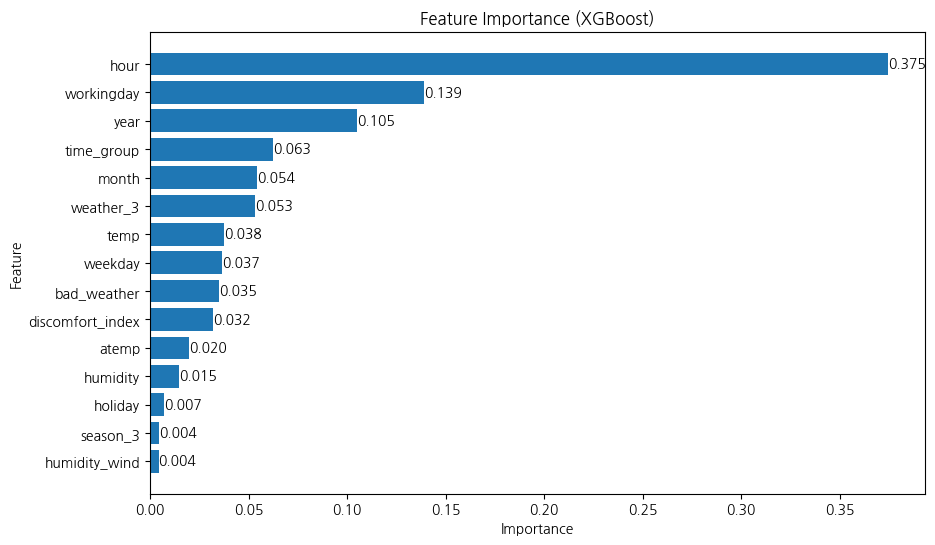

In [45]:
# 중요도 추출
importances = xgb.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# 상위 15개만 보기
top_feat = feat_imp.head(15)

plt.figure(figsize=(10,6))
bars = plt.barh(top_feat.index, top_feat.values)
plt.gca().invert_yaxis()

plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')

# 수치 표시
for i, v in enumerate(top_feat.values):
    plt.text(v, i, f'{v:.3f}', va='center')

plt.show()

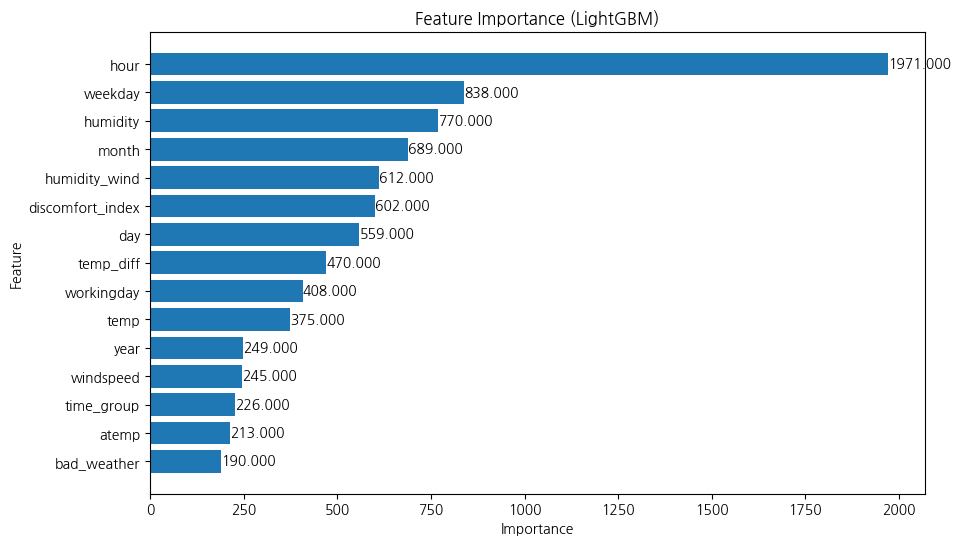

In [47]:
# 중요도 추출
importances = lgbm.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# 상위 15개만 보기
top_feat = feat_imp.head(15)

plt.figure(figsize=(10,6))
bars = plt.barh(top_feat.index, top_feat.values)
plt.gca().invert_yaxis()

plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature')

# 수치 표시
for i, v in enumerate(top_feat.values):
    plt.text(v, i, f'{v:.3f}', va='center')

plt.show()

In [48]:
#하이퍼파라미터튜닝 (XGB)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
최적 파라미터: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}


In [50]:
best_xgb = grid.best_estimator_

evaluate_model('XGBoost (Tuned)', best_xgb, X_train, X_test, y_train, y_test)

모델명 : XGBoost (Tuned)
MSE         : 1,652.84
RMSE        : 40.66
MAE         : 23.69
R²          : 0.9478  (94.78%)
NRMSE(%)    : 21.71%
NMAE(%)     : 12.65%



{'Model': 'XGBoost (Tuned)',
 'MSE': 1652.8362662289821,
 'RMSE': np.float64(40.65508905695549),
 'MAE': 23.68994843445315,
 'R2': 0.9477944701915701,
 'R2(%)': 94.77944701915702,
 'NRMSE(%)': np.float64(21.705037066845374),
 'NMAE(%)': np.float64(12.647646845911673)}